In [1]:
import scanpy as sc
import infercnvpy as cnv
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.simplefilter("ignore")
import omicverse as ov
ov.plot_set()


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.11, Tutorials: https://omicverse.readthedocs.io/
Dependency error: The 'phate>=1.0' distribution was not found and is required by the application


In [2]:
sc.logging.print_header()

scanpy==1.10.4 anndata==0.11.3 umap==0.5.7 numpy==1.26.4 scipy==1.11.4 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13


In [3]:
adata = sc.read("/home/lugli/spuccio/Projects/SP039/GBmap/RawDataConcatenate.h5ad")

In [4]:
adata.shape

(574995, 16345)

In [5]:
adata.obs.head()

,donor_id,Author,stage,assay,tissue,Cells,Method,n_genes,nUMIs,annotation_level_1,...,scsa_celltype_cellmarker,scsa_celltype_panglaodb,cell_type,S_score,G2M_score,phase,leiden,cnv_leiden,cnv_score,cnv_status
Cell1,ndGBM-01,Abdelfattah2022,Primary,10x 3' v3,frontal lobe,Total,cell,1217,1649.492065,Neoplastic,...,Astrocyte,Neural Stem/Precursor Cells,malignant cell,-0.346103,-0.145763,G1,2,12,0.012155,normal
Cell2,ndGBM-01,Abdelfattah2022,Primary,10x 3' v3,frontal lobe,Total,cell,2227,1636.858887,Neoplastic,...,Oligodendrocyte,Neurons,malignant cell,-0.107018,-0.188411,G1,8,9,0.030704,tumor
Cell3,ndGBM-01,Abdelfattah2022,Primary,10x 3' v3,frontal lobe,Total,cell,869,1436.748291,Neoplastic,...,Oligodendrocyte,Neurons,malignant cell,-0.196478,0.199244,G2M,5,4,0.026711,tumor
Cell4,ndGBM-01,Abdelfattah2022,Primary,10x 3' v3,frontal lobe,Total,cell,2809,2174.696289,Neoplastic,...,Oligodendrocyte,Neurons,malignant cell,0.667687,0.146567,S,8,9,0.030704,tumor
Cell5,ndGBM-01,Abdelfattah2022,Primary,10x 3' v3,frontal lobe,Total,cell,1735,1866.502686,Non-neoplastic,...,Oligodendrocyte,Oligodendrocytes,oligodendrocyte,-0.530942,-0.117756,G1,12,17,0.022981,tumor


In [6]:
adata=ov.pp.preprocess(adata,mode='shiftlog|pearson',
                       n_HVGs=2000,batch_key="Author")
adata

Begin robust gene identification
After filtration, 16325/16345 genes are kept.     Among 16325 genes, 15439 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['APOD', 'BPTF', 'CD74', 'CLDN5', 'CST3', 'CXCL3', 'CYB5D2', 'FOS', 'FTH1', 'FTL', 'GFAP', 'GINM1', 'HBB', 'HSPA1A', 'HSPA6', 'JCHAIN', 'MT-CO1', 'MT-CO2', 'MT-CO3', 'MT2A', 'RSRP1', 'SAT1', 'SEC61G', 'SPP1', 'TAX1BP1', 'TIMP1', 'TMSB4X', 'VIM']
    finished (0:00:07)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector

AnnData object with n_obs × n_vars = 574995 × 15439
    obs: 'donor_id', 'Author', 'stage', 'assay', 'tissue', 'Cells', 'Method', 'n_genes', 'nUMIs', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'scsa_celltype_cellmarker', 'scsa_celltype_panglaodb', 'cell_type', 'S_score', 'G2M_score', 'phase', 'leiden', 'cnv_leiden', 'cnv_score', 'cnv_status'
    var: 'ensembl_gene_id', 'start_position', 'end_position', 'chromosome_name', 'gene_biotype', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'log1p', 'hvg'
    obsm: 'X_cnv', 'X_harmony', 'X_pca', 'X_umap', 'scaled|original|X_pca'
    layers: 'counts'

In [7]:
list(adata[:,adata.var['highly_variable_features'].isin([True])].var.index)

['A2M',
 'AATK',
 'ABCA1',
 'ABCA2',
 'ABCA8',
 'ABCB1',
 'ABCG2',
 'ABHD5',
 'ABI3',
 'ABL2',
 'ABLIM1',
 'ACAN',
 'ACKR3',
 'ACP5',
 'ACSL1',
 'ACTA2',
 'ACTB',
 'ACTG2',
 'ACTN1',
 'ACTN2',
 'ACY3',
 'ADAM28',
 'ADAM8',
 'ADAMDEC1',
 'ADAMTS1',
 'ADAMTS4',
 'ADAMTS6',
 'ADAMTS8',
 'ADAMTS9',
 'ADAP2',
 'ADARB2',
 'ADCYAP1',
 'ADGRD1',
 'ADGRE2',
 'ADGRE5',
 'ADGRF5',
 'ADGRG1',
 'ADGRG3',
 'ADGRL2',
 'ADGRL4',
 'ADGRV1',
 'ADIRF',
 'ADM',
 'ADORA3',
 'ADRB2',
 'AEBP1',
 'AGT',
 'AHCYL1',
 'AHNAK',
 'AIF1',
 'AIF1L',
 'AIM2',
 'AK5',
 'AKAP12',
 'AKAP13',
 'AKNA',
 'AKR1C1',
 'AKR1C3',
 'ALCAM',
 'ALDH1A1',
 'ALDH1L1',
 'ALDOC',
 'ALOX15B',
 'ALOX5AP',
 'ALPK3',
 'AMER2',
 'ANG',
 'ANGPT2',
 'ANGPTL4',
 'ANK3',
 'ANKDD1B',
 'ANKH',
 'ANKRD18A',
 'ANKRD22',
 'ANKRD28',
 'ANKRD33B',
 'ANKRD36C',
 'ANKRD37',
 'ANKRD44',
 'ANKRD55',
 'ANKS1B',
 'ANLN',
 'ANO9',
 'ANPEP',
 'ANXA1',
 'ANXA2',
 'AOAH',
 'AP1B1',
 'APBB1IP',
 'APLN',
 'APLNR',
 'APLP1',
 'APOBEC3C',
 'APOBEC3G',
 'APOBEC3H',

In [8]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
adata

View of AnnData object with n_obs × n_vars = 574995 × 2000
    obs: 'donor_id', 'Author', 'stage', 'assay', 'tissue', 'Cells', 'Method', 'n_genes', 'nUMIs', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'scsa_celltype_cellmarker', 'scsa_celltype_panglaodb', 'cell_type', 'S_score', 'G2M_score', 'phase', 'leiden', 'cnv_leiden', 'cnv_score', 'cnv_status'
    var: 'ensembl_gene_id', 'start_position', 'end_position', 'chromosome_name', 'gene_biotype', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'log1p', 'hvg'
    obsm: 'X_cnv', 'X_harmony', 'X_pca', 'X_umap', 'scaled|original|X_pca'
    layers: 'counts'

In [9]:
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)
adata.obsm['X_pca']=adata.obsm['scaled|original|X_pca']

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50
    finished (0:01:22)


<AxesSubplot: title={'center': 'Author'}, xlabel='X_pca1', ylabel='X_pca2'>

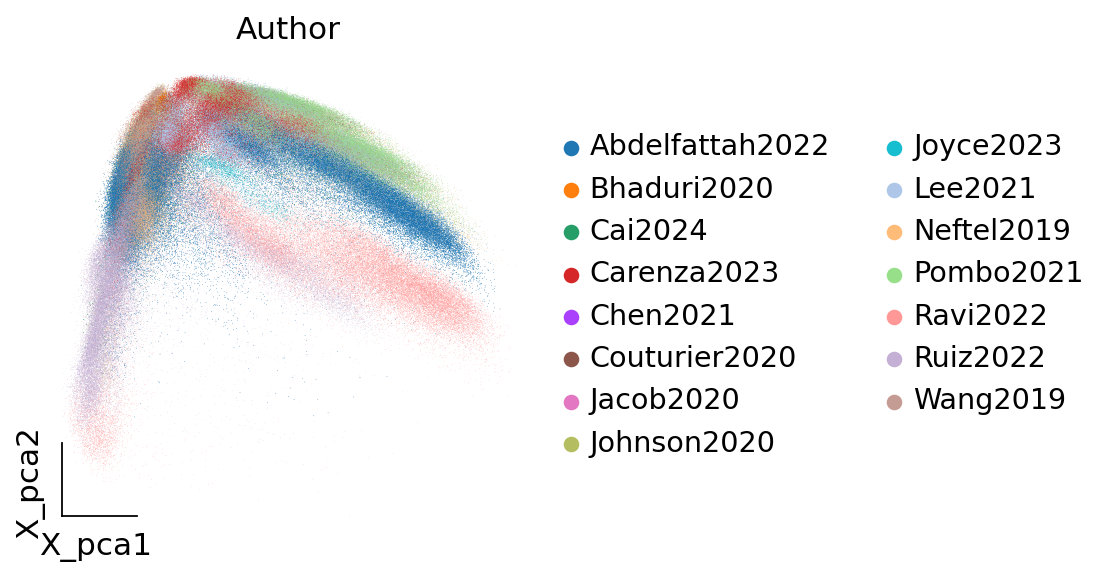

In [10]:
ov.utils.embedding(adata,
                basis='X_pca',frameon='small',
                color=['Author'],show=False,wspace=0.5)

<AxesSubplot: title={'center': 'cell_type'}, xlabel='X_pca1', ylabel='X_pca2'>

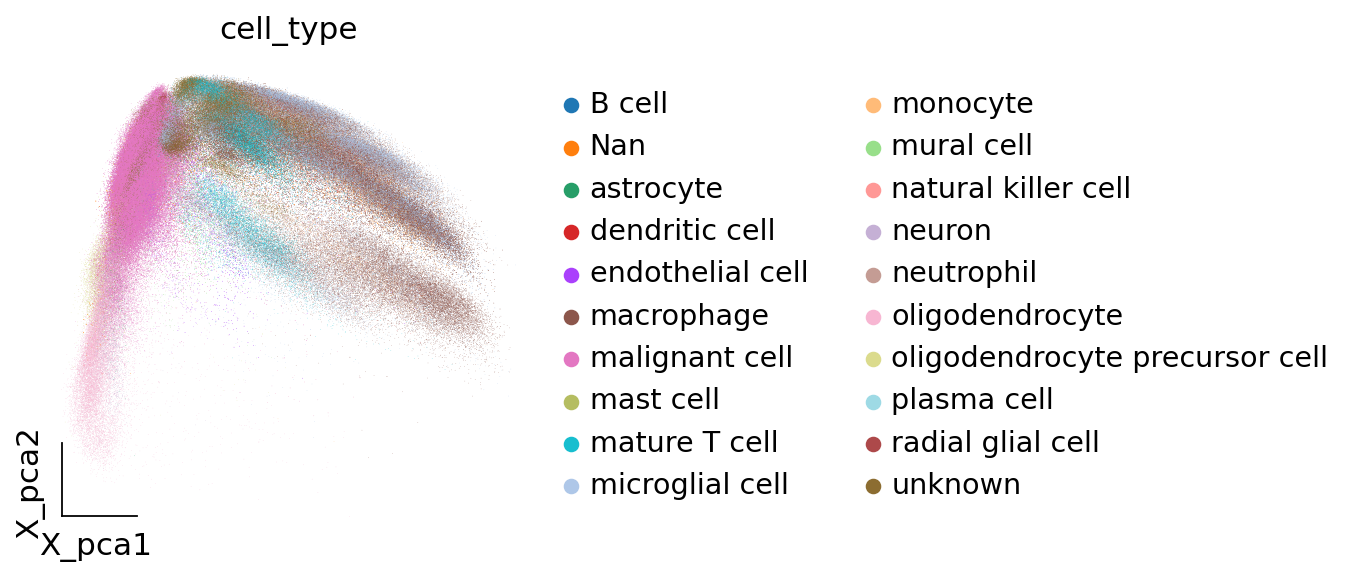

In [11]:
ov.utils.embedding(adata,
                basis='X_pca',frameon='small',
                color=['cell_type'],show=False,wspace=0.5)

In [12]:
adata.obs['Author'].value_counts()

Author
Abdelfattah2022    222578
Lee2021             68136
Couturier2020       46250
Ravi2022            40436
Ruiz2022            39124
Pombo2021           27000
Carenza2023         23430
Johnson2020         21476
Jacob2020           20968
Neftel2019          17414
Cai2024             15950
Bhaduri2020         14594
Wang2019            10659
Chen2021             4804
Joyce2023            2176
Name: count, dtype: int64

In [13]:
ov.pp.neighbors(adata, n_neighbors=15, n_pcs=50,
               use_rep='scaled|original|X_pca')


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:58)


In [14]:
%%time
ov.pp.umap(adata)


computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:20:26)
CPU times: user 3h 51min 20s, sys: 2h 6min 40s, total: 5h 58min 1s
Wall time: 20min 26s


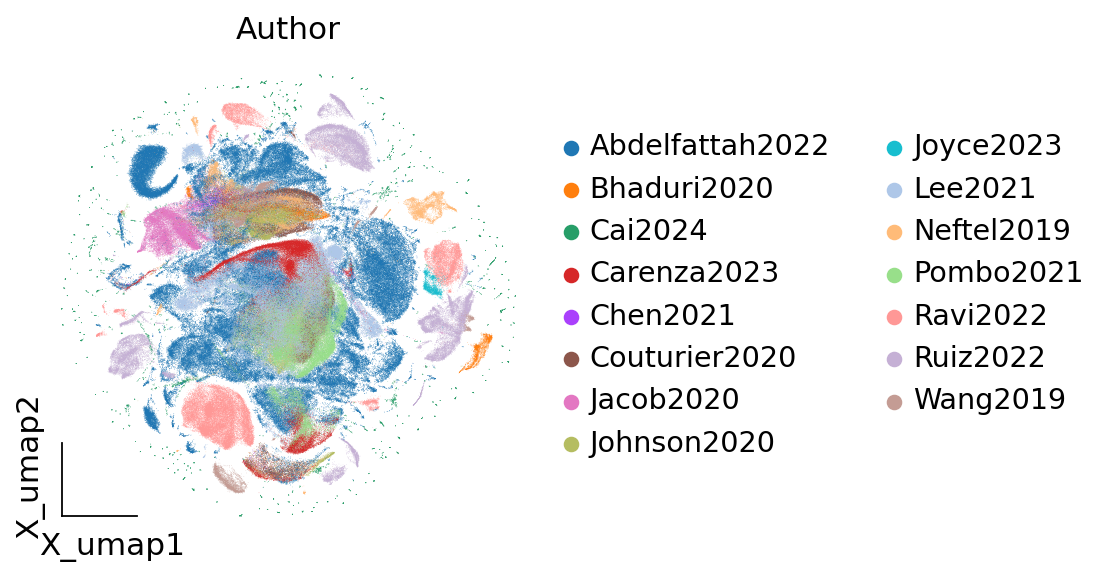

In [15]:
ov.pl.embedding(adata,
                basis='X_umap',
                color='Author',
                frameon='small')

In [16]:
ov.single.batch_correction(adata,batch_key=['Author','assay'],
                                        methods='harmony',n_pcs=30)
adata

...Begin using harmony to correct batch effect


2025-04-14 18:48:42,661 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-04-14 18:49:16,153 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-04-14 18:49:18,751 - harmonypy - INFO - Iteration 1 of 10
2025-04-14 18:54:19,851 - harmonypy - INFO - Iteration 2 of 10
2025-04-14 18:59:07,833 - harmonypy - INFO - Iteration 3 of 10
2025-04-14 19:03:50,256 - harmonypy - INFO - Converged after 3 iterations


AnnData object with n_obs × n_vars = 574995 × 2000
    obs: 'donor_id', 'Author', 'stage', 'assay', 'tissue', 'Cells', 'Method', 'n_genes', 'nUMIs', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'scsa_celltype_cellmarker', 'scsa_celltype_panglaodb', 'cell_type', 'S_score', 'G2M_score', 'phase', 'leiden', 'cnv_leiden', 'cnv_score', 'cnv_status'
    var: 'ensembl_gene_id', 'start_position', 'end_position', 'chromosome_name', 'gene_biotype', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'Author_colors', 'cell_type_colors', 'neighbors', 'umap'
    obsm: 'X_cnv', 'X_harmony', 'X_pca', 'X_umap', 'scaled|original|X_pca'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'conn

In [17]:
adata.obsm['X_harmony'].shape

(574995, 50)

In [18]:
#adata.obsm['X_pca'] = adata.obsm['X_harmony']

In [19]:
ov.pp.neighbors(adata, n_neighbors=15, n_pcs=50,
               use_rep='X_harmony')

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:36)


In [20]:
%%time
ov.pp.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:10:58)
CPU times: user 41min 53s, sys: 25min 28s, total: 1h 7min 21s
Wall time: 10min 58s


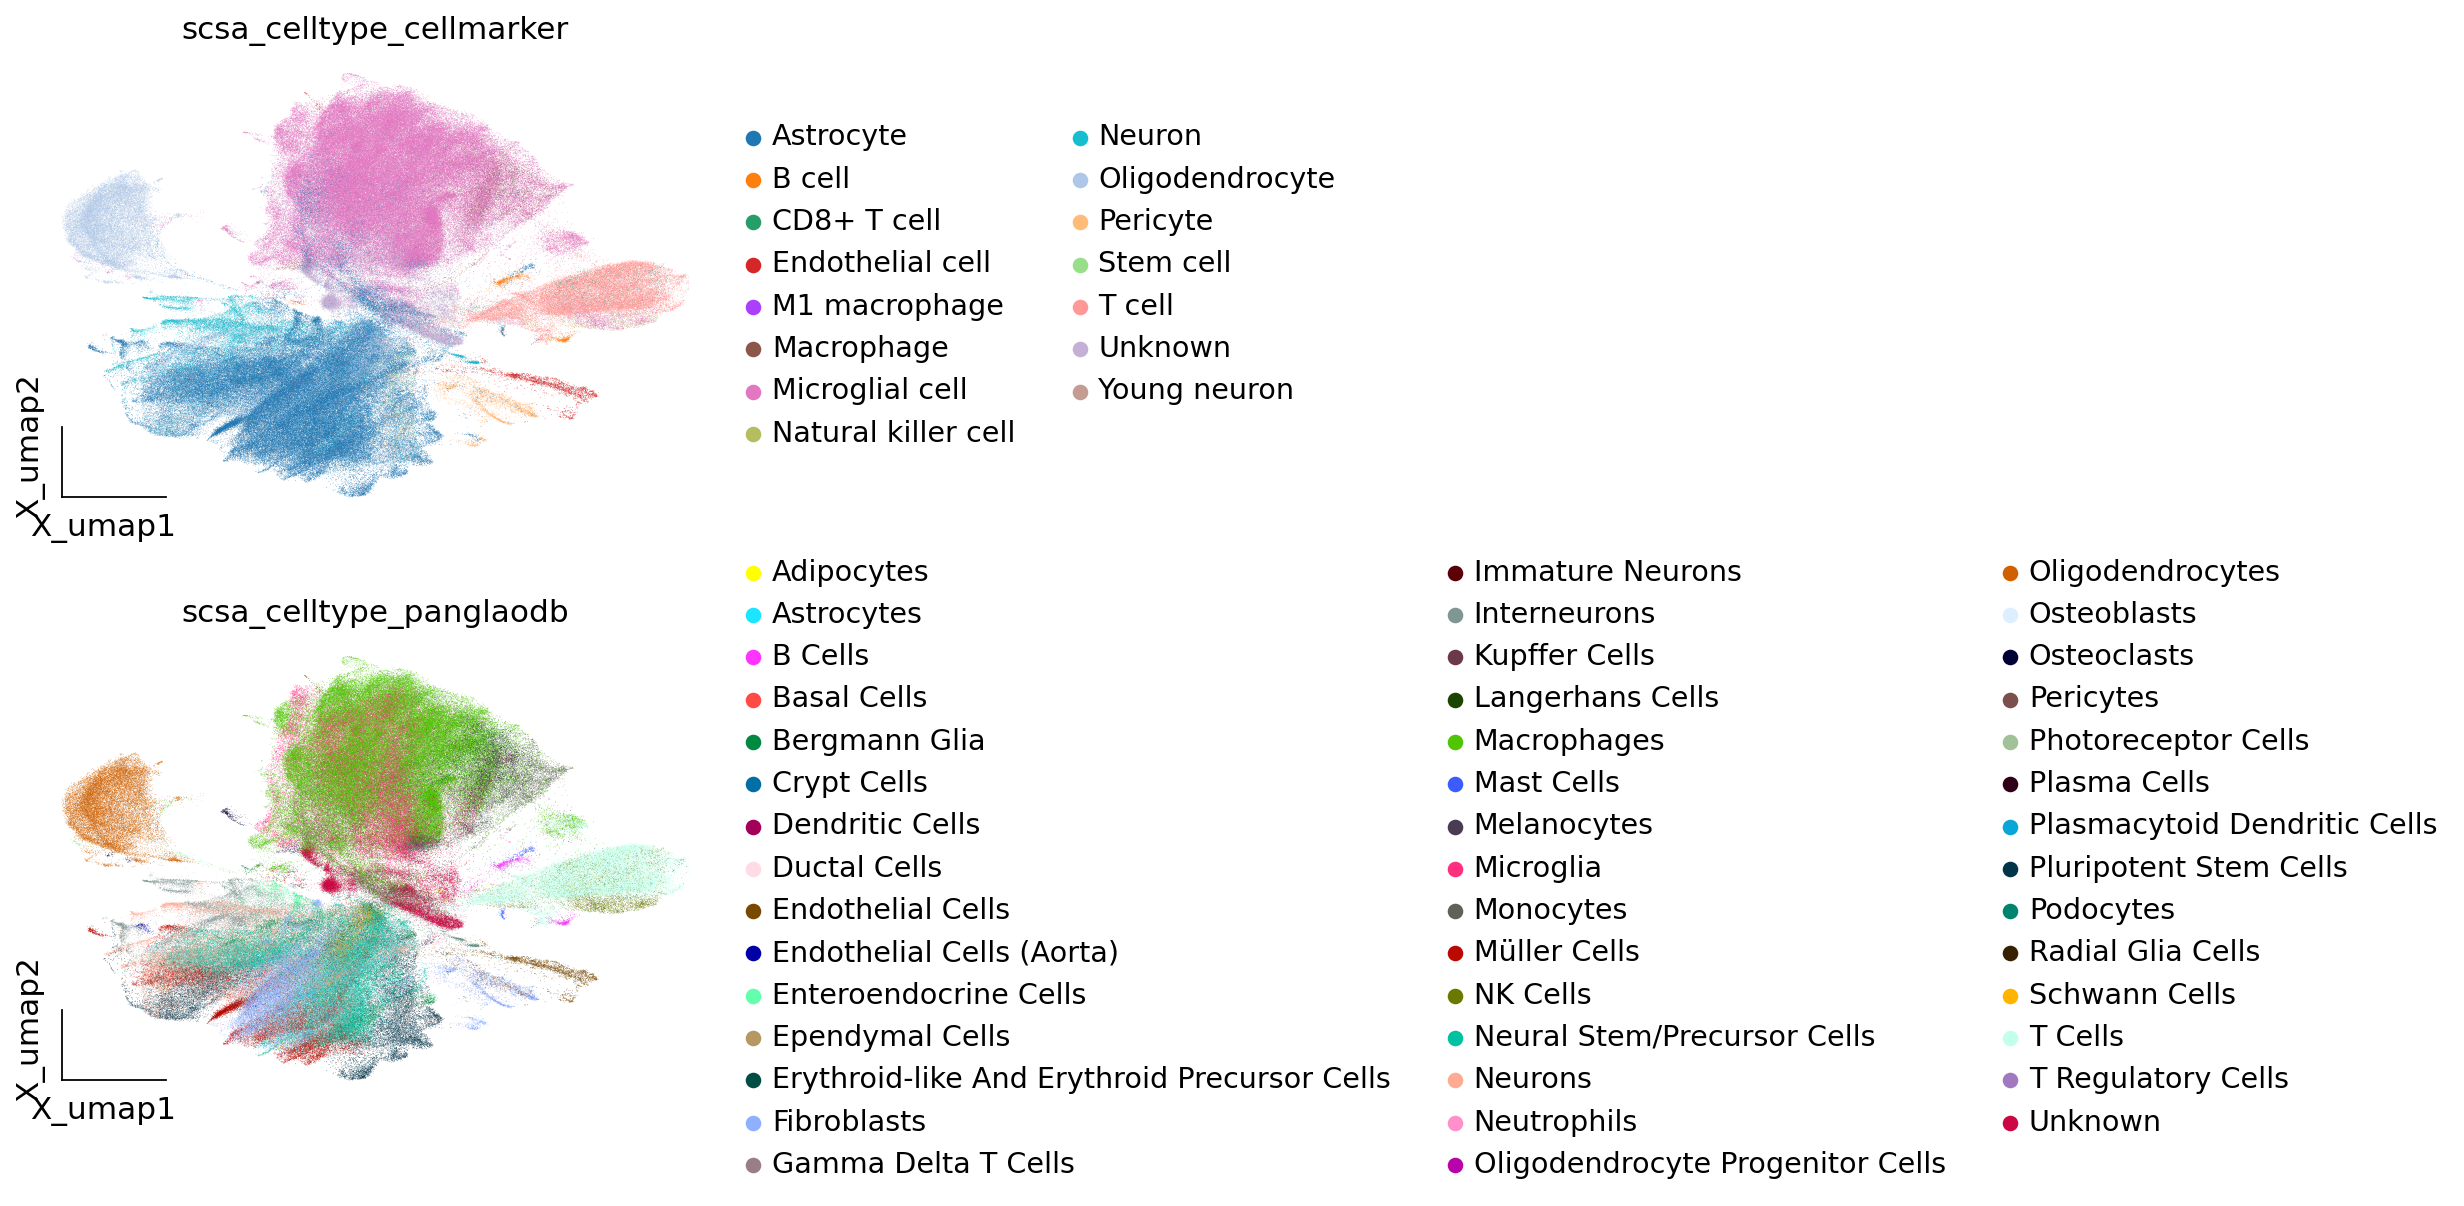

In [26]:
ov.pl.embedding(adata,
                basis='X_umap',
                color=['scsa_celltype_cellmarker','scsa_celltype_panglaodb'],wspace=0.5,ncols=1,
                frameon='small')

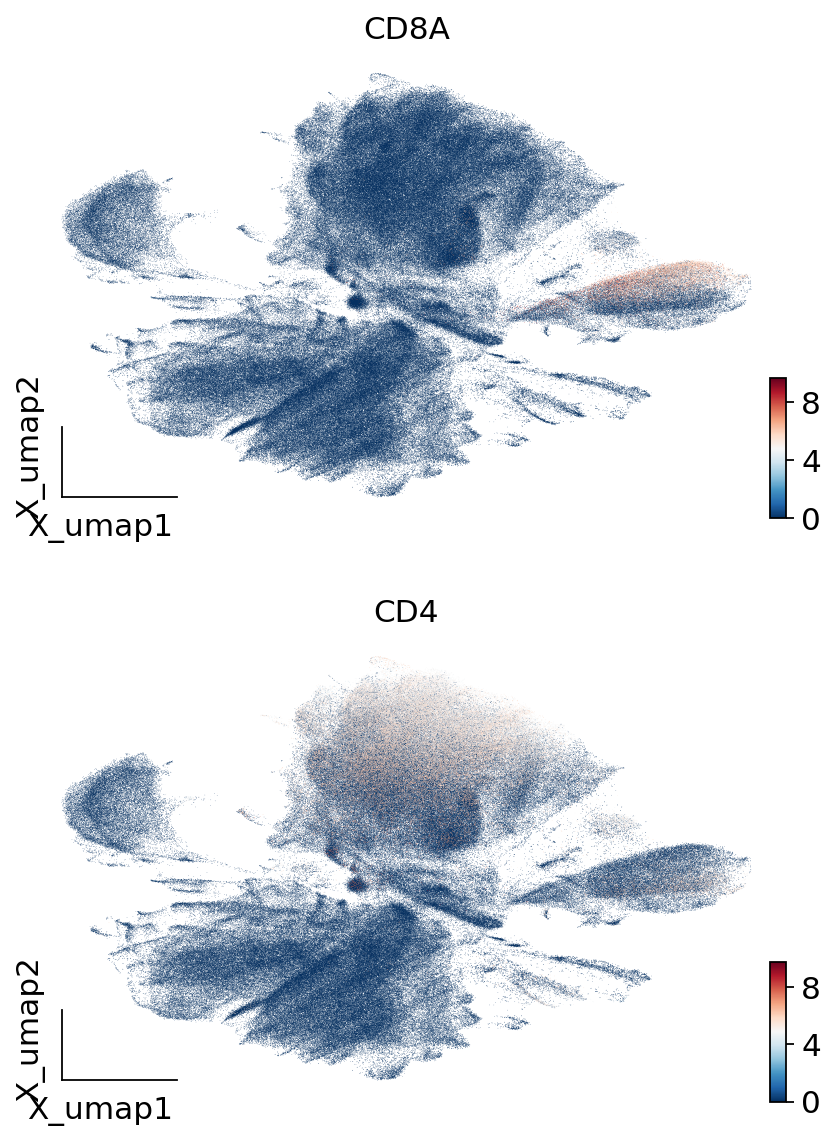

In [28]:
ov.pl.embedding(adata,
                basis='X_umap',
                color=['CD8A','CD4'],wspace=0.5,ncols=1,
                frameon='small')

In [40]:
adata.write("/home/lugli/spuccio/Projects/SP039/GBmap/RawDataAfterIntegrationHarmonyWithUnKnow.h5ad")